# PF-5039: Semana 01 - Práctica Asincrónica Desafío Avanzado
## Simulación de Aliasing Espacial, Filtro Antialiasing y Evaluación de PSNR en Retinografía

**Estudiante:** Emily Julieth Chacón Araya **Carné:** C02047
---
### Requerimientos del Desafío:
En esta práctica autónoma de 1 hora, estudiará en detalle cómo prevenir el fenómeno de Aliasing/Moiré en imágenes médicas de alta densidad cromática.

--- 
### Parte A: Simulación de Aliasing en una Grilla Sinusoidal Sintética
1. Genere una matriz de $512 \times 512$ píxeles representando la función matemática $f(x, y) = \sin(2\pi f_0 x) + \sin(2\pi f_0 y)$ con $f_0 = 15$.
2. Aplique un submuestreo por un factor de escala $S = 4$ mediante dos métodos:
   - **Método 1 (Submuestreo Directo sin Filtrado):** Tome cada $S$-ésimo píxel directo de la matriz (`pattern[::S, ::S]`).
   - **Método 2 (Submuestreo Filtrado Antialiasing):** Aplique un filtro pasa-bajo Gaussiano (`cv2.GaussianBlur`) con $\sigma = S/2 = 2.0$ y luego submuestree.
3. Grafique los 3 mapas de intensidad en paralelo e interpete la presencia de patrones Moiré.

In [69]:
# Punto 1. Generación de la matriz sinusoidal.
import numpy as np

# Número de píxeles en cada dirección.
N = 512

# Frecuencia de las ondas sinusoidales.
f0 = 15

# Coordenadas espaciales de cada píxel.
# El intervalo [0, 2*pi] permite observar 15 ciclos de la onda.
x = np.linspace(0, 2 * np.pi, N)
y = np.linspace(0, 2 * np.pi, N)

# Se crea una rejilla de coordenadas de 512 x 512.
# X contiene la coordenada horizontal y Y la coordenada vertical.
X, Y = np.meshgrid(x, y)

pattern = np.sin(2 * np.pi * f0 * X) + np.sin(2 * np.pi * f0 * Y)

print("Obtenemos:")
print(f"Matriz generada: {pattern.shape}")
print(f"Rango de intensidad: [{pattern.min():.3f}, {pattern.max():.3f}]")

Obtenemos:
Matriz generada: (512, 512)
Rango de intensidad: [-2.000, 2.000]


In [70]:
# Punto 2. Submuestreo.

import cv2

S = 4
sigma = S / 2

# Método 1: submuestreo directo sin filtrado.
pattern_directo = pattern[::S, ::S]

# Método 2: filtrado Gaussiano antes del submuestreo.
pattern_filtrado = cv2.GaussianBlur(
    pattern, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma
)
pattern_filtrado = pattern_filtrado[::S, ::S]

print("Obtenemos:")
print(f"Dimensiones del submuestreo directo: {pattern_directo.shape}")
print(f"Dimensiones del submuestreo filtrado: {pattern_filtrado.shape}")

Obtenemos:
Dimensiones del submuestreo directo: (128, 128)
Dimensiones del submuestreo filtrado: (128, 128)


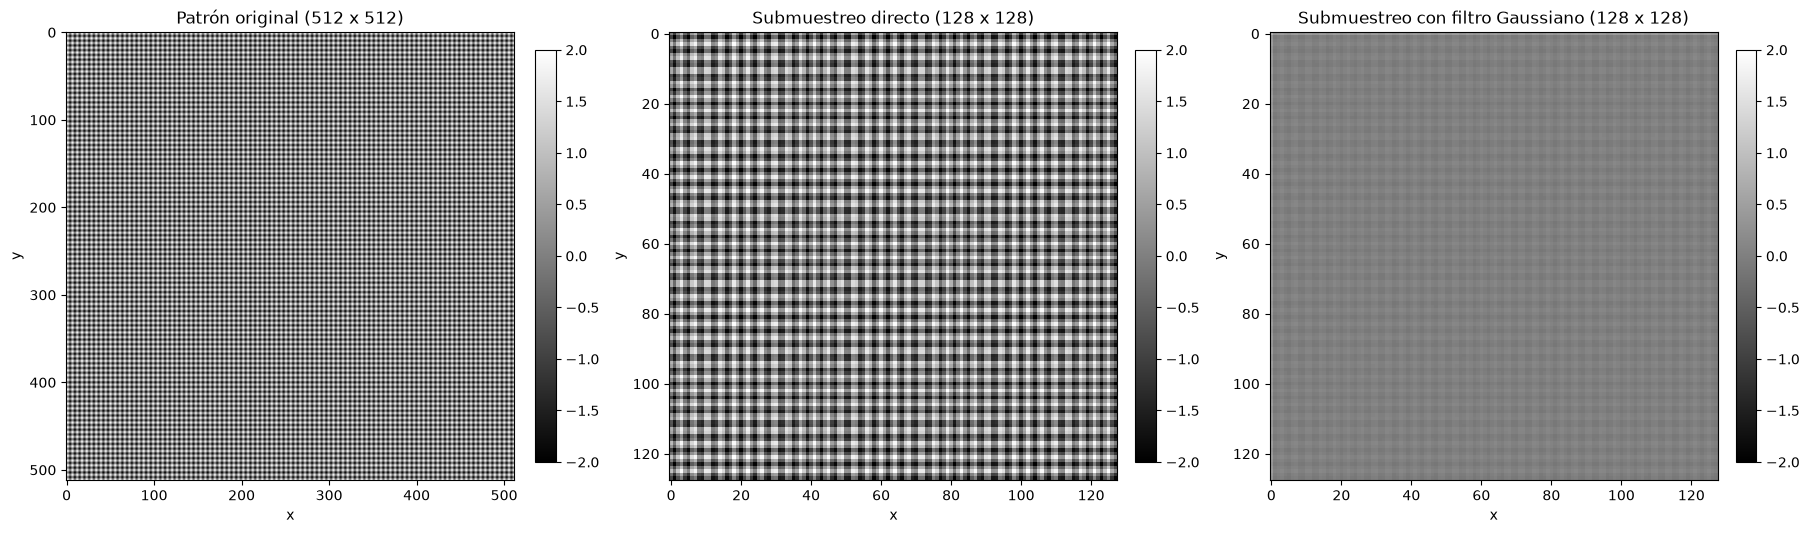

In [71]:
# Punto 3. Visualización de los mapas de intensidad.
import matplotlib.pyplot as plt

# Crea una figura con una fila y tres espacios para imágenes.
fig, ejes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# Imagen 1: patrón original.
# imshow() interpreta cada valor de la matriz como la intensidad de un píxel.
imagen_original = ejes[0].imshow(
    pattern, cmap="gray", vmin=-2, vmax=2
)
ejes[0].set_title("Patrón original (512 x 512)")
ejes[0].set_xlabel("x")
ejes[0].set_ylabel("y")
fig.colorbar(imagen_original, ax=ejes[0], fraction=0.046, pad=0.04)

# Imagen 2: submuestreo directo.
# Se muestra la matriz que conserva un píxel de cada cuatro.
imagen_directa = ejes[1].imshow(
    pattern_directo, cmap="gray", vmin=-2, vmax=2
)
ejes[1].set_title("Submuestreo directo (128 x 128)")
ejes[1].set_xlabel("x")
ejes[1].set_ylabel("y")
fig.colorbar(imagen_directa, ax=ejes[1], fraction=0.046, pad=0.04)

# Imagen 3: filtro Gaussiano y submuestreo.
# Se muestra la matriz suavizada antes de reducir su resolución.
imagen_filtrada = ejes[2].imshow(
    pattern_filtrado, cmap="gray", vmin=-2, vmax=2
)
ejes[2].set_title("Submuestreo con filtro Gaussiano (128 x 128)")
ejes[2].set_xlabel("x")
ejes[2].set_ylabel("y")
fig.colorbar(imagen_filtrada, ax=ejes[2], fraction=0.046, pad=0.04)

# Se muestra la figura completa.
plt.show()

### Interpretación de la Parte A

Esta experiencia utiliza una imagen creada matemáticamente para observar qué ocurre cuando una imagen se hace más pequeña.

- **Patrón original:** es la imagen completa. Está formada por muchas líneas claras y oscuras que se cruzan. Las zonas claras tienen valores más altos y las zonas oscuras tienen valores más bajos.
- **Submuestreo directo:** para reducir la imagen, se conserva solo un píxel de cada cuatro. Es parecido a hacer una fotografía más pequeña eliminando parte de la información sin preparar la imagen. El resultado conserva la forma general, pero puede perder detalles o mostrar formas que no estaban en la imagen original.
- **Filtro Gaussiano y submuestreo:** antes de reducir la imagen, se aplica un pequeño desenfoque. Es parecido a suavizar la imagen antes de hacerla más pequeña. Así se eliminan algunos detalles demasiado finos y se evita que se conviertan en formas falsas.

El **aliasing** ocurre cuando una imagen tiene detalles muy pequeños y se reduce demasiado: esos detalles pueden verse diferentes de lo que eran originalmente. En algunos casos aparecen líneas, ondas o rejillas que no existían; este efecto visual se conoce como **Moiré**. En esta figura, el submuestreo directo conserva una cuadrícula más marcada, mientras que el resultado con filtro Gaussiano se ve más suave y uniforme.

En conclusión, el submuestreo directo mantiene más cambios bruscos, pero tiene mayor riesgo de producir errores visuales. El filtro Gaussiano reduce algunos detalles, pero permite obtener una imagen más estable al disminuir su tamaño.

--- 
### Parte B: Evaluación Cuantitativa de PSNR en Submuestreo de Retinografía
1. Cargue la imagen médica `retinografia_microaneurismas.png` ($512 \times 512$).
2. Reduzca la resolución espacial a $128 \times 128$ ($S=4$) mediante submuestreo directo y submuestreo con filtro Gaussiano.
3. Vuelva a escalar ambas imágenes reducidas a la dimensión original de $512 \times 512$ (`cv2.INTER_NEAREST`) para poder compararlas matriz a matriz con la original.
4. Calcule la métrica PSNR (dB) para ambos métodos y concluya cuál preserva mejor la fidelidad estructural de la vascularización retiniana.

Dimensiones de la imagen: 512 x 512 pixeles


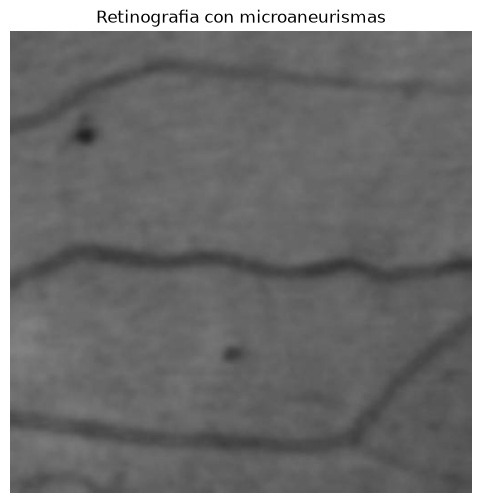

In [72]:
# Punto 1. Cargar imagen.
import cv2
import matplotlib.pyplot as plt

ruta_imagen = "imagenes/retinografia_microaneurismas.png"
imagen = cv2.imread(ruta_imagen, cv2.IMREAD_COLOR)

if imagen is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen: {ruta_imagen}")

alto, ancho = imagen.shape[:2]
print(f"Dimensiones de la imagen: {ancho} x {alto} pixeles")

if (alto, ancho) != (512, 512):
    raise ValueError(f"Se esperaba una imagen de 512 x 512, pero se obtuvo {ancho} x {alto}")

imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.imshow(imagen_rgb)
plt.title("Retinografia con microaneurismas")
plt.axis("off")
plt.show()

In [73]:
# Punto 2. Reducción de la imagen.

# S = 4 significa que se conserva un píxel de cada cuatro.
S = 4
sigma = S / 2

# Método 1: submuestreo directo, sin aplicar ningún filtro.
imagen_reducida_directa = imagen[::S, ::S]

# Método 2: primero se suaviza la imagen con un filtro Gaussiano.
imagen_suavizada = cv2.GaussianBlur(
    imagen, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma
)

# Después del suavizado, se conserva un píxel de cada cuatro.
imagen_reducida_gaussiana = imagen_suavizada[::S, ::S]

print("Se obtiene:")
print(f"Imagen original: {ancho} x {alto} píxeles")
print(
    f"Submuestreo directo: {imagen_reducida_directa.shape[1]} x "
    f"{imagen_reducida_directa.shape[0]} píxeles"
)
print(
    f"Gaussiano + submuestreo: {imagen_reducida_gaussiana.shape[1]} x "
    f"{imagen_reducida_gaussiana.shape[0]} píxeles"
)

Se obtiene:
Imagen original: 512 x 512 píxeles
Submuestreo directo: 128 x 128 píxeles
Gaussiano + submuestreo: 128 x 128 píxeles


In [74]:
# Punto 3. Reescalado a la resolución original.

# Se define el tamaño original de la imagen.
# OpenCV recibe las dimensiones en el orden (ancho, alto).
tamano_original = (ancho, alto)

# Se amplía la imagen reducida mediante submuestreo directo.
# INTER_NEAREST repite cada píxel sin crear valores intermedios.
imagen_directa_reescalada = cv2.resize(
    imagen_reducida_directa,
    tamano_original,
    interpolation=cv2.INTER_NEAREST,
)

# Se amplía la imagen reducida después del filtro Gaussiano.
imagen_gaussiana_reescalada = cv2.resize(
    imagen_reducida_gaussiana,
    tamano_original,
    interpolation=cv2.INTER_NEAREST,
)

print("Se obtiene:")
print(
    f"Imagen original: {imagen.shape[1]} x {imagen.shape[0]} píxeles"
)
print(
    f"Submuestreo directo reescalado: "
    f"{imagen_directa_reescalada.shape[1]} x "
    f"{imagen_directa_reescalada.shape[0]} píxeles"
)
print(
    f"Gaussiano + submuestreo reescalado: "
    f"{imagen_gaussiana_reescalada.shape[1]} x "
    f"{imagen_gaussiana_reescalada.shape[0]} píxeles"
)

Se obtiene:
Imagen original: 512 x 512 píxeles
Submuestreo directo reescalado: 512 x 512 píxeles
Gaussiano + submuestreo reescalado: 512 x 512 píxeles


In [75]:
# Parte B - Punto 4. Cálculo de PSNR.

# PSNR compara cada resultado con la imagen original.
# Un valor mayor significa que la imagen se parece más a la original.
psnr_directo = cv2.PSNR(
    imagen,
    imagen_directa_reescalada,
)

psnr_gaussiano = cv2.PSNR(
    imagen,
    imagen_gaussiana_reescalada,
)

print(f"PSNR - Submuestreo directo: {psnr_directo:.2f} dB")
print(f"PSNR - Gaussiano + submuestreo: {psnr_gaussiano:.2f} dB")

if psnr_directo > psnr_gaussiano:
    print("El submuestreo directo conservó mejor la imagen.")
elif psnr_gaussiano > psnr_directo:
    print("El método Gaussiano conservó mejor la imagen.")
else:
    print("Ambos métodos conservaron la imagen por igual.")

PSNR - Submuestreo directo: 41.49 dB
PSNR - Gaussiano + submuestreo: 41.52 dB
El método Gaussiano conservó mejor la imagen.


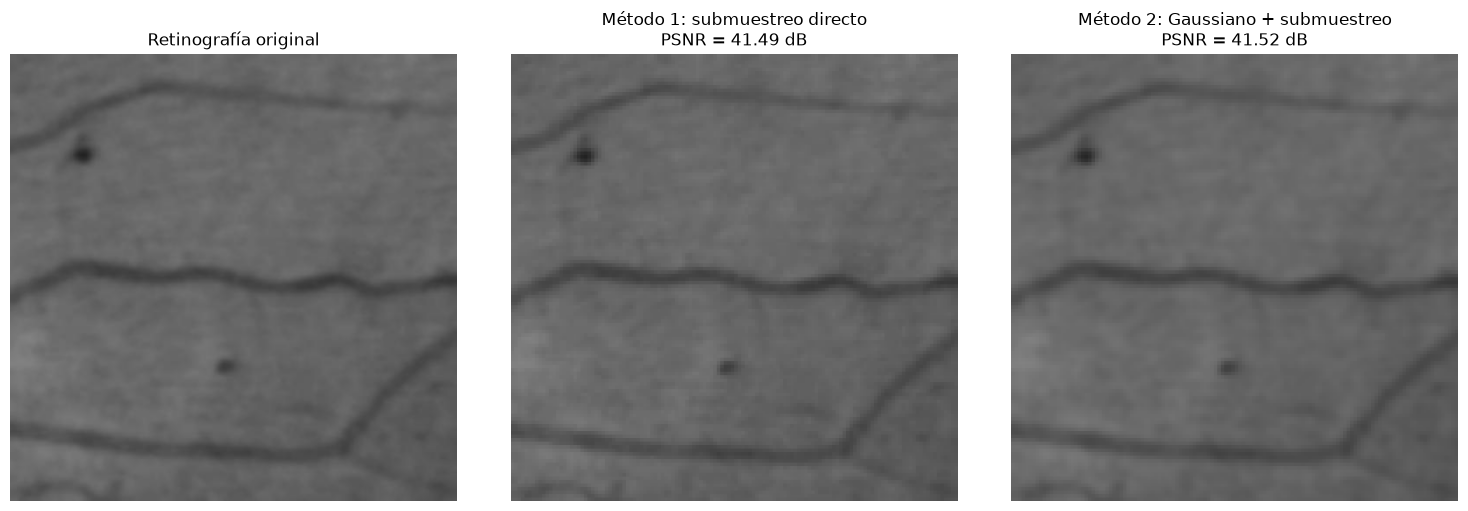

In [76]:
# Parte B. Visualización de los resultados.

# OpenCV lee las imágenes en formato BGR.
# Se convierten a RGB para mostrarlas correctamente con matplotlib.
imagen_original_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
imagen_directa_rgb = cv2.cvtColor(
    imagen_directa_reescalada, cv2.COLOR_BGR2RGB
)
imagen_gaussiana_rgb = cv2.cvtColor(
    imagen_gaussiana_reescalada, cv2.COLOR_BGR2RGB
)

# Se crea una figura con la imagen original y los dos resultados.
fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# Imagen original.
ejes[0].imshow(imagen_original_rgb)
ejes[0].set_title("Retinografía original")
ejes[0].axis("off")

# Resultado del submuestreo directo.
ejes[1].imshow(imagen_directa_rgb)
ejes[1].set_title(
    f"Método 1: submuestreo directo\nPSNR = {psnr_directo:.2f} dB"
)
ejes[1].axis("off")

# Resultado del filtro Gaussiano y submuestreo.
ejes[2].imshow(imagen_gaussiana_rgb)
ejes[2].set_title(
    f"Método 2: Gaussiano + submuestreo\n"
    f"PSNR = {psnr_gaussiano:.2f} dB"
)
ejes[2].axis("off")

plt.show()

### Interpretación de la Parte B

La figura permite comparar la retinografía original con las dos versiones procesadas:

- **Retinografía original:** contiene todos los píxeles y detalles de la imagen médica.
- **Método 1: submuestreo directo:** se toma un píxel de cada cuatro para hacer la imagen más pequeña. Después se vuelve a ampliar para poder compararla con la original. Al ampliar, algunos píxeles se repiten, por lo que la imagen puede verse un poco más pixelada y perder algunos detalles pequeños.
- **Método 2: filtro Gaussiano + submuestreo:** primero se suaviza la imagen y luego se reduce. Después también se vuelve a ampliar. Por eso esta versión puede verse un poco más suave, pero evita mejor cambios bruscos y detalles falsos.

Visualmente, las tres imágenes siguen mostrando la misma retinografía y se pueden reconocer sus estructuras principales. Las diferencias se observan sobre todo en los detalles pequeños y en la nitidez de los bordes.

El valor PSNR sirve para medir qué tan parecida es cada imagen procesada a la original. Un valor más alto significa mayor parecido. En este caso, el submuestreo directo obtuvo **41.49 dB** y el método Gaussiano obtuvo **41.52 dB**. Como el valor Gaussiano es ligeramente mayor, este método conservó un poco mejor la información de la imagen original.

La diferencia es pequeña, pero el filtro Gaussiano es preferible porque reduce el riesgo de perder información importante o crear cambios que no estaban en la retinografía.